# Experiment 8: Effect of PCA on Regression and Classification Models


## 1. Import Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, make_scorer

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Dataset

In [17]:
# Row 0 of the CSV contains column names, so read with header=None first
df_raw = pd.read_csv(r"C:\Users\janis\ML\Dataset.csv", header=None)

# Set row 0 as the header and drop it from data
df_raw.columns = df_raw.iloc[0].str.strip()
df = df_raw.drop(index=0).reset_index(drop=True)

# Correct target column names
regression_target     = 'Final_Score_Regression'
classification_target = 'Performance_Level_Classification'

# Feature columns = all except the two targets
feature_cols = [col for col in df.columns if col not in [regression_target, classification_target]]

# Convert features and regression target to numeric
df[feature_cols]      = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df[regression_target] = pd.to_numeric(df[regression_target], errors='coerce')

print('Dataset loaded successfully!')
print(f'Shape         : {df.shape}')
print(f'Samples       : {df.shape[0]}')
print(f'Total Columns : {df.shape[1]}')
print(f'Feature Cols  : {len(feature_cols)}')
print(f'\nFeature columns: {feature_cols}')
print(f'\nRegression Target    : {regression_target}')
print(f'Classification Target: {classification_target}')
df.head()

Dataset loaded successfully!
Shape         : (1000, 13)
Samples       : 1000
Total Columns : 13
Feature Cols  : 11

Feature columns: ['Math', 'Physics', 'Chemistry', 'Biology', 'Total_Science', 'Average_Science', 'English', 'Computer_Science', 'Sports_Score', 'Attendance_Percentage', 'Random_Noise_Feature']

Regression Target    : Final_Score_Regression
Classification Target: Performance_Level_Classification


,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


## 3. Dataset Overview

In [18]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df[feature_cols + [regression_target]].describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Math                              1000 non-null   float64
 1   Physics                           1000 non-null   float64
 2   Chemistry                         1000 non-null   float64
 3   Biology                           1000 non-null   float64
 4   Total_Science                     1000 non-null   float64
 5   Average_Science                   1000 non-null   float64
 6   English                           1000 non-null   float64
 7   Computer_Science                  1000 non-null   float64
 8   Sports_Score                      1000 non-null   float64
 9   Attendance_Percentage             1000 non-null   float64
 10  Random_Noise_Feature              1000 non-null   float64
 11  Final_Score_Regression            1000 non-null  

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,70.547502,70.222492,70.099724,69.897679,280.767397,70.098374,68.910072,71.289176,60.275127,84.939829,-1.995426,66.621902
std,10.808021,11.054274,10.996436,11.300320,40.221715,10.247065,10.513340,10.939763,15.175282,4.825616,48.520180,10.243337
min,40.281107,40.714289,33.064255,34.674721,159.256015,39.353154,33.780309,36.313866,2.450167,65.387999,-161.628272,37.230851
25%,63.486805,62.489626,62.431330,62.274814,253.402127,63.235427,61.365478,63.726518,50.447182,81.783329,-34.344974,59.931376
50%,70.482400,69.858079,69.897283,69.889763,279.889174,70.056315,68.681014,71.255254,60.286860,85.021831,-2.815709,66.712433
75%,77.318218,78.032674,77.745564,77.668212,307.528100,76.963283,76.192147,79.071257,70.158061,88.253711,30.616752,73.707292
max,117.275199,108.523772,110.783442,101.770991,438.353403,109.713013,104.958147,109.904708,110.660744,98.841868,145.705461,111.586769


## 4. Target Distribution

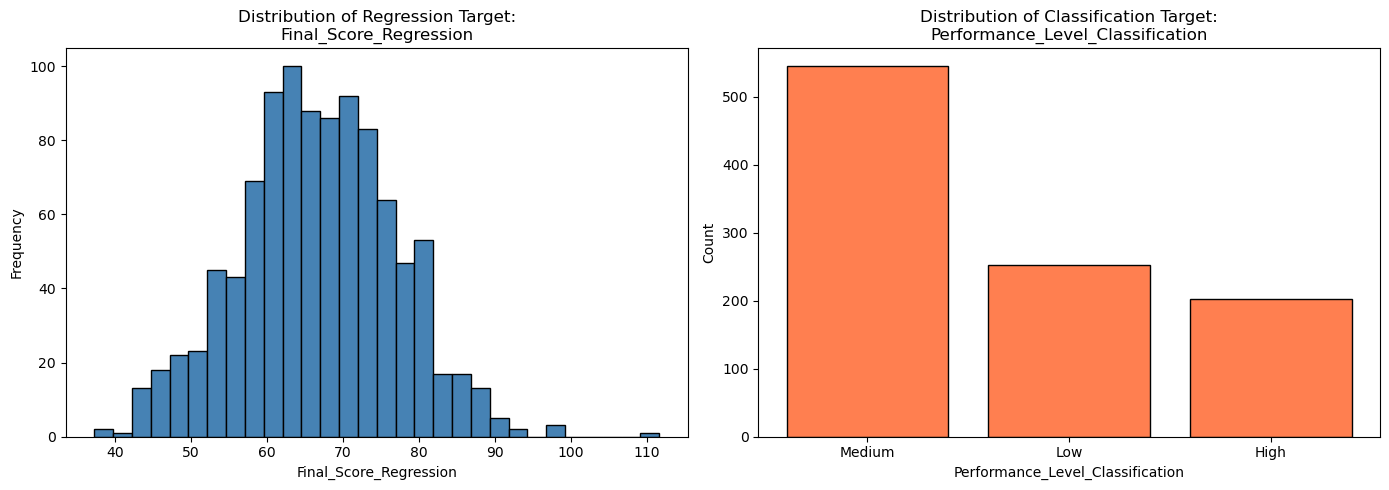


Regression Target - Final_Score_Regression:
count    1000.000000
mean       66.621902
std        10.243337
min        37.230851
25%        59.931376
50%        66.712433
75%        73.707292
max       111.586769
Name: Final_Score_Regression, dtype: float64

Classification Target - Performance_Level_Classification:
Performance_Level_Classification
Medium    545
Low       253
High      202
Name: count, dtype: int64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression target
axes[0].hist(df[regression_target].astype(float), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title(f'Distribution of Regression Target:\n{regression_target}')
axes[0].set_xlabel(regression_target)
axes[0].set_ylabel('Frequency')

# Classification target
class_counts = df[classification_target].value_counts()
axes[1].bar(class_counts.index, class_counts.values, color='coral', edgecolor='black')
axes[1].set_title(f'Distribution of Classification Target:\n{classification_target}')
axes[1].set_xlabel(classification_target)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRegression Target - Final_Score_Regression:')
print(df[regression_target].astype(float).describe())
print('\nClassification Target - Performance_Level_Classification:')
print(df[classification_target].value_counts())

## 5. Preprocessing Steps

In [20]:
# Step 1: Handle missing values
print('=== Step 1: Missing Value Check ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
print(f'Missing values after handling: {df.isnull().sum().sum()}')

=== Step 1: Missing Value Check ===
No missing values found!
Missing values after handling: 0


In [21]:
# Step 2: Encode categorical target for classification
print('=== Step 2: Encode Categorical Target ===')
le    = LabelEncoder()
y_cls = le.fit_transform(df[classification_target])
print(f'Original classes : {le.classes_}')
print(f'Encoded values   : {np.unique(y_cls)}')
print(f'Label mapping    : {dict(zip(le.classes_, le.transform(le.classes_)))}')

=== Step 2: Encode Categorical Target ===
Original classes : ['High' 'Low' 'Medium']
Encoded values   : [0 1 2]
Label mapping    : {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [22]:
# Step 3: Extract X and y
X     = df[feature_cols].values.astype(float)
y_reg = df[regression_target].values.astype(float)

print(f'Features matrix shape       : {X.shape}')
print(f'Regression target shape     : {y_reg.shape}')
print(f'Classification target shape : {y_cls.shape}')

Features matrix shape       : (1000, 11)
Regression target shape     : (1000,)
Classification target shape : (1000,)


In [23]:
# Step 4: Standardize features — VERY IMPORTANT before PCA
print('=== Step 4: Standardize Features ===')
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Mean of scaled features (should be ~0): {X_scaled.mean(axis=0).round(3)}')
print(f'Std  of scaled features (should be ~1): {X_scaled.std(axis=0).round(3)}')
print('Standardization complete!')

=== Step 4: Standardize Features ===
Mean of scaled features (should be ~0): [ 0. -0.  0.  0.  0. -0. -0.  0.  0. -0.  0.]
Std  of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Standardization complete!


## 6. PCA Implementation

In [24]:
# Full PCA to study explained variance
pca_full            = PCA()
pca_full.fit(X_scaled)
explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_var_ratio)

print('Explained variance per component:')
for i, (v, c) in enumerate(zip(explained_var_ratio, cumulative_variance)):
    print(f'  PC{i+1:02d}: {v*100:.2f}%  |  Cumulative: {c*100:.2f}%')

Explained variance per component:
  PC01: 56.97%  |  Cumulative: 56.97%
  PC02: 9.76%  |  Cumulative: 66.74%
  PC03: 8.92%  |  Cumulative: 75.66%
  PC04: 8.66%  |  Cumulative: 84.32%
  PC05: 5.36%  |  Cumulative: 89.68%
  PC06: 3.89%  |  Cumulative: 93.57%
  PC07: 2.32%  |  Cumulative: 95.90%
  PC08: 2.04%  |  Cumulative: 97.93%
  PC09: 1.78%  |  Cumulative: 99.71%
  PC10: 0.29%  |  Cumulative: 100.00%
  PC11: 0.00%  |  Cumulative: 100.00%


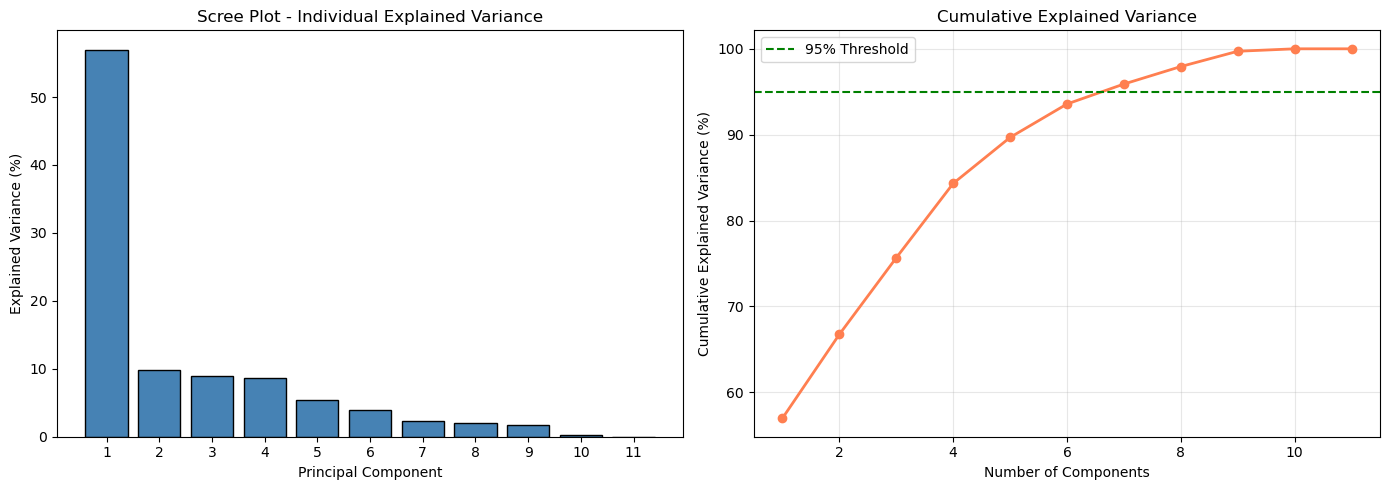

Components needed for 95% variance : 7
Actual variance retained           : 95.90%


In [25]:
# Scree Plot
n_total = len(explained_var_ratio)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, n_total + 1), explained_var_ratio * 100, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot - Individual Explained Variance')
axes[0].set_xticks(range(1, n_total + 1))

axes[1].plot(range(1, n_total + 1), cumulative_variance * 100,
             marker='o', markersize=6, color='coral', linewidth=2)
axes[1].axhline(y=95, color='green', linestyle='--', linewidth=1.5, label='95% Threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Components needed for 95% variance : {n_components_95}')
print(f'Actual variance retained           : {cumulative_variance[n_components_95-1]*100:.2f}%')

In [26]:
# Apply PCA retaining 95% variance
pca   = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

n_components_chosen = pca.n_components_
explained_var_total = pca.explained_variance_ratio_.sum() * 100

print(f'Original features    : {X_scaled.shape[1]}')
print(f'PCA components chosen: {n_components_chosen}')
print(f'Explained variance   : {explained_var_total:.2f}%')
print(f'Reduced shape        : {X_pca.shape}')

Original features    : 11
PCA components chosen: 7
Explained variance   : 95.90%
Reduced shape        : (1000, 7)


## Table 1: PCA Summary

In [27]:
pca_summary = pd.DataFrame({
    'Components Chosen'     : [n_components_chosen],
    'Explained Variance (%)': [f'{explained_var_total:.2f}%'],
    'Justification'         : [
        f'Retain 95% explained variance; reduced from {X_scaled.shape[1]} '
        f'to {n_components_chosen} components, minimizing information loss '
        f'while reducing dimensionality and multicollinearity.'
    ]
})

print('\n' + '='*80)
print('TABLE 1: PCA Summary')
print('='*80)
print(pca_summary.to_string(index=False))
print('='*80)
pca_summary


TABLE 1: PCA Summary
 Components Chosen Explained Variance (%)                                                                                                                                    Justification
                 7                 95.90% Retain 95% explained variance; reduced from 11 to 7 components, minimizing information loss while reducing dimensionality and multicollinearity.


,Components Chosen,Explained Variance (%),Justification
0,7,95.90%,Retain 95% explained variance; reduced from 11...


## 7. Regression Models
### Setup: 5-Fold Cross Validation

In [28]:
kf         = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer  = make_scorer(r2_score)
print('5-Fold CV for Regression ready.')

5-Fold CV for Regression ready.


### 7.1 Linear Regression

In [29]:
lr = LinearRegression()

# Without PCA
cv_lr_nopca  = cross_validate(lr, X_scaled, y_reg, cv=kf, scoring={'mse': mse_scorer, 'r2': r2_scorer})
lr_mse_nopca = -cv_lr_nopca['test_mse']
lr_r2_nopca  =  cv_lr_nopca['test_r2']

# With PCA
cv_lr_pca  = cross_validate(lr, X_pca, y_reg, cv=kf, scoring={'mse': mse_scorer, 'r2': r2_scorer})
lr_mse_pca = -cv_lr_pca['test_mse']
lr_r2_pca  =  cv_lr_pca['test_r2']

print('LINEAR REGRESSION RESULTS')
print('-' * 65)
print(f"{'Fold':<8} {'MSE (No PCA)':>14} {'MSE (PCA)':>12} {'R2 (No PCA)':>13} {'R2 (PCA)':>11}")
print('-' * 65)
for i in range(5):
    print(f"Fold {i+1:<3} {lr_mse_nopca[i]:>14.4f} {lr_mse_pca[i]:>12.4f} "
          f"{lr_r2_nopca[i]:>13.4f} {lr_r2_pca[i]:>11.4f}")
print('-' * 65)
print(f"{'Avg':<8} {lr_mse_nopca.mean():>14.4f} {lr_mse_pca.mean():>12.4f} "
      f"{lr_r2_nopca.mean():>13.4f} {lr_r2_pca.mean():>11.4f}")
print(f"{'Std':<8} {lr_mse_nopca.std():>14.4f} {lr_mse_pca.std():>12.4f} "
      f"{lr_r2_nopca.std():>13.4f} {lr_r2_pca.std():>11.4f}")

LINEAR REGRESSION RESULTS
-----------------------------------------------------------------
Fold       MSE (No PCA)    MSE (PCA)   R2 (No PCA)    R2 (PCA)
-----------------------------------------------------------------
Fold 1          28.3983      28.7366        0.7554      0.7525
Fold 2          23.2668      23.0044        0.7590      0.7618
Fold 3          28.1602      28.2939        0.7169      0.7156
Fold 4          26.4605      26.4592        0.7457      0.7457
Fold 5          24.8834      24.6311        0.7625      0.7649
-----------------------------------------------------------------
Avg             26.2338      26.2251        0.7479      0.7481
Std              1.9532       2.1705        0.0165      0.0176


### 7.2 Random Forest Regressor

In [30]:
rf_param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}

# Tune Without PCA
rf_grid_nopca = GridSearchCV(RandomForestRegressor(random_state=42),
                              rf_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid_nopca.fit(X_scaled, y_reg)
print(f'Best Params (No PCA)  : {rf_grid_nopca.best_params_}')

# Tune With PCA
rf_grid_pca = GridSearchCV(RandomForestRegressor(random_state=42),
                            rf_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid_pca.fit(X_pca, y_reg)
print(f'Best Params (With PCA): {rf_grid_pca.best_params_}')

Best Params (No PCA)  : {'max_depth': 5, 'n_estimators': 200}
Best Params (With PCA): {'max_depth': 5, 'n_estimators': 200}


In [31]:
cv_rf_nopca  = cross_validate(rf_grid_nopca.best_estimator_, X_scaled, y_reg, cv=kf,
                               scoring={'mse': mse_scorer, 'r2': r2_scorer})
rf_mse_nopca = -cv_rf_nopca['test_mse']
rf_r2_nopca  =  cv_rf_nopca['test_r2']

cv_rf_pca  = cross_validate(rf_grid_pca.best_estimator_, X_pca, y_reg, cv=kf,
                             scoring={'mse': mse_scorer, 'r2': r2_scorer})
rf_mse_pca = -cv_rf_pca['test_mse']
rf_r2_pca  =  cv_rf_pca['test_r2']

print('RANDOM FOREST REGRESSOR RESULTS')
print('-' * 65)
print(f"{'Fold':<8} {'MSE (No PCA)':>14} {'MSE (PCA)':>12} {'R2 (No PCA)':>13} {'R2 (PCA)':>11}")
print('-' * 65)
for i in range(5):
    print(f"Fold {i+1:<3} {rf_mse_nopca[i]:>14.4f} {rf_mse_pca[i]:>12.4f} "
          f"{rf_r2_nopca[i]:>13.4f} {rf_r2_pca[i]:>11.4f}")
print('-' * 65)
print(f"{'Avg':<8} {rf_mse_nopca.mean():>14.4f} {rf_mse_pca.mean():>12.4f} "
      f"{rf_r2_nopca.mean():>13.4f} {rf_r2_pca.mean():>11.4f}")
print(f"{'Std':<8} {rf_mse_nopca.std():>14.4f} {rf_mse_pca.std():>12.4f} "
      f"{rf_r2_nopca.std():>13.4f} {rf_r2_pca.std():>11.4f}")

RANDOM FOREST REGRESSOR RESULTS
-----------------------------------------------------------------
Fold       MSE (No PCA)    MSE (PCA)   R2 (No PCA)    R2 (PCA)
-----------------------------------------------------------------
Fold 1          32.0020      31.6593        0.7243      0.7273
Fold 2          26.0554      24.0423        0.7302      0.7510
Fold 3          29.9881      29.6695        0.6985      0.7017
Fold 4          29.5062      27.6164        0.7164      0.7346
Fold 5          26.0574      25.5162        0.7513      0.7564
-----------------------------------------------------------------
Avg             28.7219      27.7007        0.7241      0.7342
Std              2.3318       2.7462        0.0172      0.0194


## Table 2: 5-Fold CV Results – Regression

In [32]:
def obs_reg(metric, v_no, v_pca):
    diff = v_pca - v_no
    if metric == 'MSE':
        return (f"PCA {'reduces' if diff < 0 else 'increases'} MSE "
                f"({v_no:.4f} -> {v_pca:.4f}); "
                f"{'improved prediction error' if diff < 0 else 'slight info loss'}")
    else:
        return (f"PCA {'improves' if diff > 0 else 'slightly reduces'} R2 "
                f"({v_no:.4f} -> {v_pca:.4f}); "
                f"{'better fit' if diff > 0 else 'minor variance loss'}")

reg_table = pd.DataFrame({
    'Model'             : ['Linear Regression', 'Linear Regression', 'Random Forest', 'Random Forest'],
    'Metric'            : ['MSE', 'R2', 'MSE', 'R2'],
    'Fold Avg (No PCA)' : [
        f'{lr_mse_nopca.mean():.4f} +/- {lr_mse_nopca.std():.4f}',
        f'{lr_r2_nopca.mean():.4f} +/- {lr_r2_nopca.std():.4f}',
        f'{rf_mse_nopca.mean():.4f} +/- {rf_mse_nopca.std():.4f}',
        f'{rf_r2_nopca.mean():.4f} +/- {rf_r2_nopca.std():.4f}'
    ],
    'Fold Avg (With PCA)': [
        f'{lr_mse_pca.mean():.4f} +/- {lr_mse_pca.std():.4f}',
        f'{lr_r2_pca.mean():.4f} +/- {lr_r2_pca.std():.4f}',
        f'{rf_mse_pca.mean():.4f} +/- {rf_mse_pca.std():.4f}',
        f'{rf_r2_pca.mean():.4f} +/- {rf_r2_pca.std():.4f}'
    ],
    'Observation': [
        obs_reg('MSE', lr_mse_nopca.mean(), lr_mse_pca.mean()),
        obs_reg('R2',  lr_r2_nopca.mean(),  lr_r2_pca.mean()),
        obs_reg('MSE', rf_mse_nopca.mean(), rf_mse_pca.mean()),
        obs_reg('R2',  rf_r2_nopca.mean(),  rf_r2_pca.mean())
    ]
})

print('\n' + '='*100)
print('TABLE 2: 5-Fold CV Results - Regression')
print('='*100)
print(reg_table.to_string(index=False))
print('='*100)
reg_table


TABLE 2: 5-Fold CV Results - Regression
            Model Metric  Fold Avg (No PCA) Fold Avg (With PCA)                                                     Observation
Linear Regression    MSE 26.2338 +/- 1.9532  26.2251 +/- 2.1705 PCA reduces MSE (26.2338 -> 26.2251); improved prediction error
Linear Regression     R2  0.7479 +/- 0.0165   0.7481 +/- 0.0176                  PCA improves R2 (0.7479 -> 0.7481); better fit
    Random Forest    MSE 28.7219 +/- 2.3318  27.7007 +/- 2.7462 PCA reduces MSE (28.7219 -> 27.7007); improved prediction error
    Random Forest     R2  0.7241 +/- 0.0172   0.7342 +/- 0.0194                  PCA improves R2 (0.7241 -> 0.7342); better fit


,Model,Metric,Fold Avg (No PCA),Fold Avg (With PCA),Observation
0,Linear Regression,MSE,26.2338 +/- 1.9532,26.2251 +/- 2.1705,PCA reduces MSE (26.2338 -> 26.2251); improved...
1,Linear Regression,R2,0.7479 +/- 0.0165,0.7481 +/- 0.0176,PCA improves R2 (0.7479 -> 0.7481); better fit
2,Random Forest,MSE,28.7219 +/- 2.3318,27.7007 +/- 2.7462,PCA reduces MSE (28.7219 -> 27.7007); improved...
3,Random Forest,R2,0.7241 +/- 0.0172,0.7342 +/- 0.0194,PCA improves R2 (0.7241 -> 0.7342); better fit


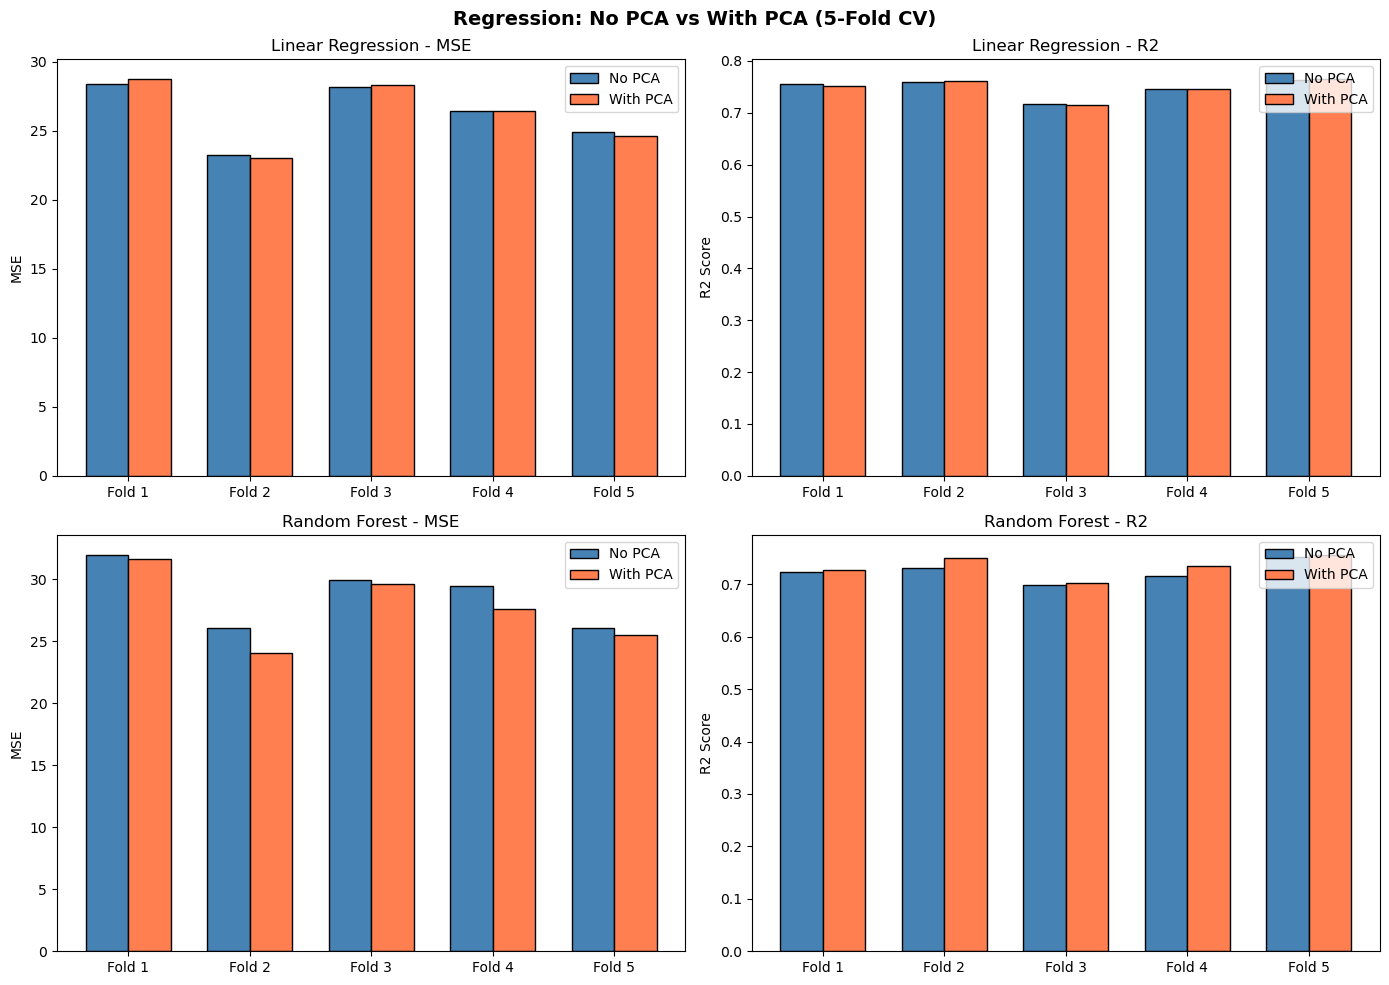

In [33]:
# Regression Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x, w = np.arange(5), 0.35
folds = [f'Fold {i+1}' for i in range(5)]

pairs = [
    (axes[0,0], lr_mse_nopca, lr_mse_pca, 'Linear Regression - MSE',  'MSE'),
    (axes[0,1], lr_r2_nopca,  lr_r2_pca,  'Linear Regression - R2',   'R2 Score'),
    (axes[1,0], rf_mse_nopca, rf_mse_pca, 'Random Forest - MSE',      'MSE'),
    (axes[1,1], rf_r2_nopca,  rf_r2_pca,  'Random Forest - R2',       'R2 Score'),
]
for ax, nopca, wpca, title, ylabel in pairs:
    ax.bar(x - w/2, nopca, w, label='No PCA',   color='steelblue', edgecolor='black')
    ax.bar(x + w/2, wpca,  w, label='With PCA', color='coral',     edgecolor='black')
    ax.set_title(title); ax.set_xticks(x); ax.set_xticklabels(folds)
    ax.set_ylabel(ylabel); ax.legend()

plt.suptitle('Regression: No PCA vs With PCA (5-Fold CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Classification Models
### Setup: Stratified 5-Fold CV

In [34]:
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score, average='weighted')
print('Stratified 5-Fold CV for Classification ready.')
print(f'Classes: {le.classes_}')

Stratified 5-Fold CV for Classification ready.
Classes: ['High' 'Low' 'Medium']


### 8.1 Logistic Regression

In [35]:
log_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

log_grid_nopca = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                               log_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
log_grid_nopca.fit(X_scaled, y_cls)
print(f'Best C (No PCA)  : {log_grid_nopca.best_params_["C"]}')

log_grid_pca = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                             log_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
log_grid_pca.fit(X_pca, y_cls)
print(f'Best C (With PCA): {log_grid_pca.best_params_["C"]}')

Best C (No PCA)  : 0.1
Best C (With PCA): 0.1


In [36]:
cv_log_nopca  = cross_validate(log_grid_nopca.best_estimator_, X_scaled, y_cls, cv=skf,
                                scoring={'accuracy': 'accuracy', 'f1': f1_scorer})
log_acc_nopca = cv_log_nopca['test_accuracy']
log_f1_nopca  = cv_log_nopca['test_f1']

cv_log_pca  = cross_validate(log_grid_pca.best_estimator_, X_pca, y_cls, cv=skf,
                              scoring={'accuracy': 'accuracy', 'f1': f1_scorer})
log_acc_pca = cv_log_pca['test_accuracy']
log_f1_pca  = cv_log_pca['test_f1']

print('LOGISTIC REGRESSION RESULTS')
print('-' * 65)
print(f"{'Fold':<8} {'Acc (No PCA)':>14} {'Acc (PCA)':>12} {'F1 (No PCA)':>13} {'F1 (PCA)':>11}")
print('-' * 65)
for i in range(5):
    print(f"Fold {i+1:<3} {log_acc_nopca[i]:>14.4f} {log_acc_pca[i]:>12.4f} "
          f"{log_f1_nopca[i]:>13.4f} {log_f1_pca[i]:>11.4f}")
print('-' * 65)
print(f"{'Avg':<8} {log_acc_nopca.mean():>14.4f} {log_acc_pca.mean():>12.4f} "
      f"{log_f1_nopca.mean():>13.4f} {log_f1_pca.mean():>11.4f}")
print(f"{'Std':<8} {log_acc_nopca.std():>14.4f} {log_acc_pca.std():>12.4f} "
      f"{log_f1_nopca.std():>13.4f} {log_f1_pca.std():>11.4f}")

LOGISTIC REGRESSION RESULTS
-----------------------------------------------------------------
Fold       Acc (No PCA)    Acc (PCA)   F1 (No PCA)    F1 (PCA)
-----------------------------------------------------------------
Fold 1           0.7750       0.7600        0.7726      0.7575
Fold 2           0.7750       0.7600        0.7714      0.7544
Fold 3           0.7550       0.7650        0.7525      0.7635
Fold 4           0.7650       0.7600        0.7604      0.7566
Fold 5           0.6650       0.6700        0.6636      0.6687
-----------------------------------------------------------------
Avg              0.7470       0.7430        0.7441      0.7401
Std              0.0417       0.0366        0.0409      0.0358


### 8.2 Support Vector Machine (SVM)

In [37]:
svm_param_grid = {
    'kernel': ['linear', 'rbf'],
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 'auto']
}

svm_grid_nopca = GridSearchCV(SVC(random_state=42), svm_param_grid,
                               cv=3, scoring='accuracy', n_jobs=-1)
svm_grid_nopca.fit(X_scaled, y_cls)
print(f'Best Params (No PCA)  : {svm_grid_nopca.best_params_}')

svm_grid_pca = GridSearchCV(SVC(random_state=42), svm_param_grid,
                             cv=3, scoring='accuracy', n_jobs=-1)
svm_grid_pca.fit(X_pca, y_cls)
print(f'Best Params (With PCA): {svm_grid_pca.best_params_}')

Best Params (No PCA)  : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Params (With PCA): {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [38]:
cv_svm_nopca  = cross_validate(svm_grid_nopca.best_estimator_, X_scaled, y_cls, cv=skf,
                                scoring={'accuracy': 'accuracy', 'f1': f1_scorer})
svm_acc_nopca = cv_svm_nopca['test_accuracy']
svm_f1_nopca  = cv_svm_nopca['test_f1']

cv_svm_pca  = cross_validate(svm_grid_pca.best_estimator_, X_pca, y_cls, cv=skf,
                              scoring={'accuracy': 'accuracy', 'f1': f1_scorer})
svm_acc_pca = cv_svm_pca['test_accuracy']
svm_f1_pca  = cv_svm_pca['test_f1']

print('SVM RESULTS')
print('-' * 65)
print(f"{'Fold':<8} {'Acc (No PCA)':>14} {'Acc (PCA)':>12} {'F1 (No PCA)':>13} {'F1 (PCA)':>11}")
print('-' * 65)
for i in range(5):
    print(f"Fold {i+1:<3} {svm_acc_nopca[i]:>14.4f} {svm_acc_pca[i]:>12.4f} "
          f"{svm_f1_nopca[i]:>13.4f} {svm_f1_pca[i]:>11.4f}")
print('-' * 65)
print(f"{'Avg':<8} {svm_acc_nopca.mean():>14.4f} {svm_acc_pca.mean():>12.4f} "
      f"{svm_f1_nopca.mean():>13.4f} {svm_f1_pca.mean():>11.4f}")
print(f"{'Std':<8} {svm_acc_nopca.std():>14.4f} {svm_acc_pca.std():>12.4f} "
      f"{svm_f1_nopca.std():>13.4f} {svm_f1_pca.std():>11.4f}")

SVM RESULTS
-----------------------------------------------------------------
Fold       Acc (No PCA)    Acc (PCA)   F1 (No PCA)    F1 (PCA)
-----------------------------------------------------------------
Fold 1           0.7750       0.7900        0.7730      0.7881
Fold 2           0.7700       0.7700        0.7673      0.7661
Fold 3           0.7650       0.7750        0.7628      0.7727
Fold 4           0.7450       0.7550        0.7404      0.7510
Fold 5           0.6900       0.6800        0.6891      0.6785
-----------------------------------------------------------------
Avg              0.7490       0.7540        0.7466      0.7513
Std              0.0312       0.0387        0.0308      0.0383


## Table 3: 5-Fold CV Results – Classification

In [39]:
def obs_cls(metric, v_no, v_pca):
    diff = v_pca - v_no
    if diff > 0.01:
        return f'PCA improves {metric} ({v_no:.4f} -> {v_pca:.4f}); dimensionality reduction helps'
    elif diff < -0.01:
        return f'PCA reduces {metric} ({v_no:.4f} -> {v_pca:.4f}); slight info loss'
    else:
        return f'Minimal change in {metric} ({v_no:.4f} -> {v_pca:.4f}); PCA has little effect'

cls_table = pd.DataFrame({
    'Model'             : ['Logistic Regression', 'Logistic Regression', 'SVM', 'SVM'],
    'Metric'            : ['Accuracy', 'F1-score', 'Accuracy', 'F1-score'],
    'Fold Avg (No PCA)' : [
        f'{log_acc_nopca.mean():.4f} +/- {log_acc_nopca.std():.4f}',
        f'{log_f1_nopca.mean():.4f} +/- {log_f1_nopca.std():.4f}',
        f'{svm_acc_nopca.mean():.4f} +/- {svm_acc_nopca.std():.4f}',
        f'{svm_f1_nopca.mean():.4f} +/- {svm_f1_nopca.std():.4f}'
    ],
    'Fold Avg (With PCA)': [
        f'{log_acc_pca.mean():.4f} +/- {log_acc_pca.std():.4f}',
        f'{log_f1_pca.mean():.4f} +/- {log_f1_pca.std():.4f}',
        f'{svm_acc_pca.mean():.4f} +/- {svm_acc_pca.std():.4f}',
        f'{svm_f1_pca.mean():.4f} +/- {svm_f1_pca.std():.4f}'
    ],
    'Observation': [
        obs_cls('Accuracy', log_acc_nopca.mean(), log_acc_pca.mean()),
        obs_cls('F1',       log_f1_nopca.mean(),  log_f1_pca.mean()),
        obs_cls('Accuracy', svm_acc_nopca.mean(), svm_acc_pca.mean()),
        obs_cls('F1',       svm_f1_nopca.mean(),  svm_f1_pca.mean())
    ]
})

print('\n' + '='*100)
print('TABLE 3: 5-Fold CV Results - Classification')
print('='*100)
print(cls_table.to_string(index=False))
print('='*100)
cls_table


TABLE 3: 5-Fold CV Results - Classification
              Model   Metric Fold Avg (No PCA) Fold Avg (With PCA)                                                          Observation
Logistic Regression Accuracy 0.7470 +/- 0.0417   0.7430 +/- 0.0366 Minimal change in Accuracy (0.7470 -> 0.7430); PCA has little effect
Logistic Regression F1-score 0.7441 +/- 0.0409   0.7401 +/- 0.0358       Minimal change in F1 (0.7441 -> 0.7401); PCA has little effect
                SVM Accuracy 0.7490 +/- 0.0312   0.7540 +/- 0.0387 Minimal change in Accuracy (0.7490 -> 0.7540); PCA has little effect
                SVM F1-score 0.7466 +/- 0.0308   0.7513 +/- 0.0383       Minimal change in F1 (0.7466 -> 0.7513); PCA has little effect


,Model,Metric,Fold Avg (No PCA),Fold Avg (With PCA),Observation
0,Logistic Regression,Accuracy,0.7470 +/- 0.0417,0.7430 +/- 0.0366,Minimal change in Accuracy (0.7470 -> 0.7430);...
1,Logistic Regression,F1-score,0.7441 +/- 0.0409,0.7401 +/- 0.0358,Minimal change in F1 (0.7441 -> 0.7401); PCA h...
2,SVM,Accuracy,0.7490 +/- 0.0312,0.7540 +/- 0.0387,Minimal change in Accuracy (0.7490 -> 0.7540);...
3,SVM,F1-score,0.7466 +/- 0.0308,0.7513 +/- 0.0383,Minimal change in F1 (0.7466 -> 0.7513); PCA h...


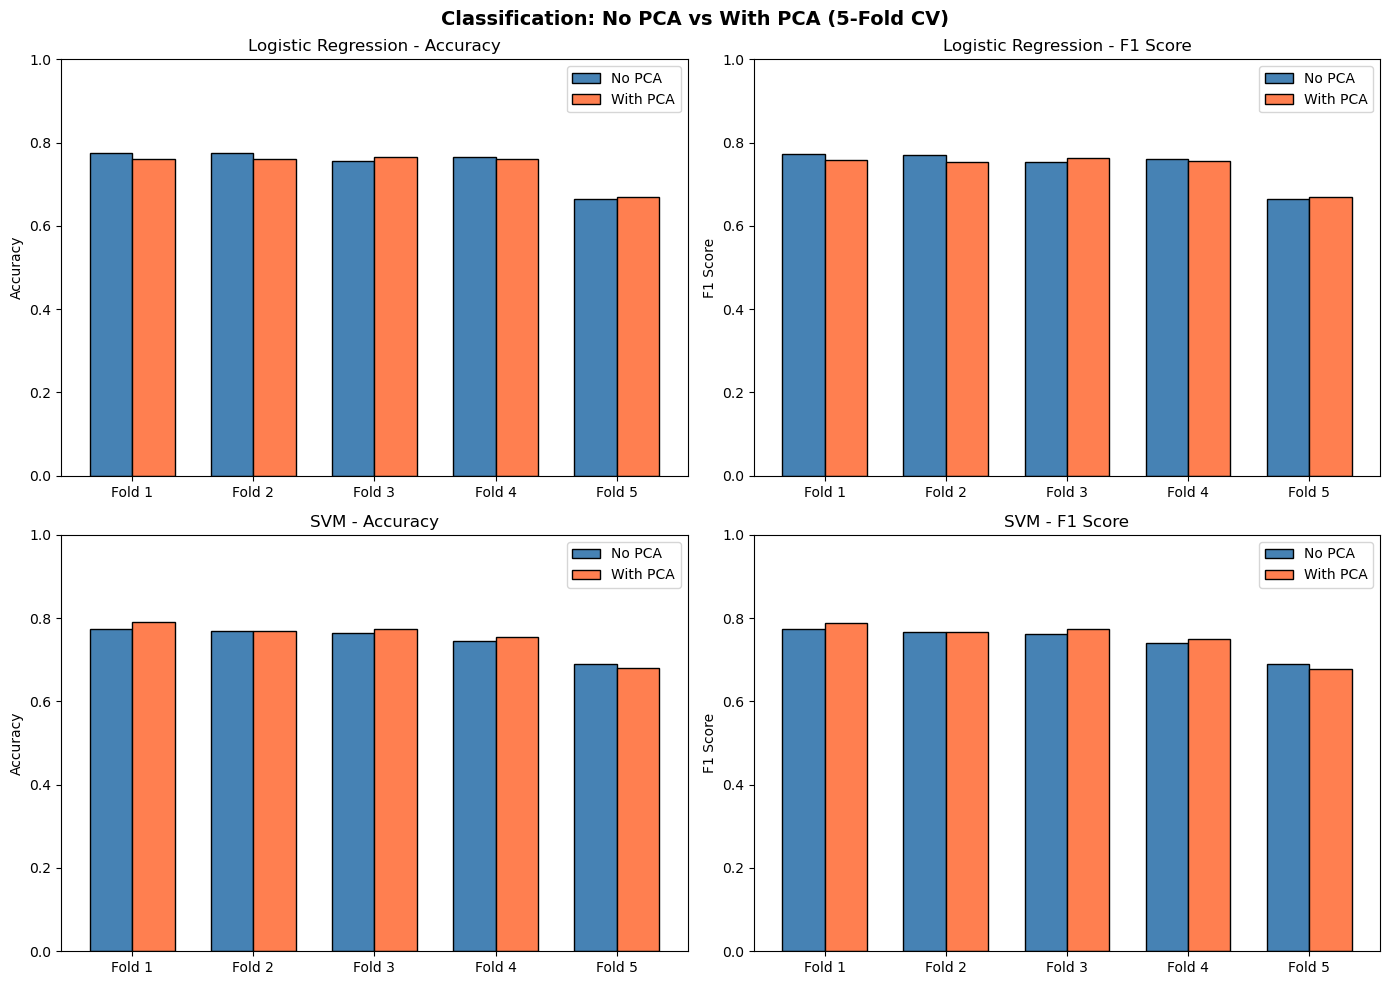

In [40]:
# Classification Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x, w = np.arange(5), 0.35

pairs = [
    (axes[0,0], log_acc_nopca, log_acc_pca, 'Logistic Regression - Accuracy', 'Accuracy'),
    (axes[0,1], log_f1_nopca,  log_f1_pca,  'Logistic Regression - F1 Score', 'F1 Score'),
    (axes[1,0], svm_acc_nopca, svm_acc_pca, 'SVM - Accuracy',                 'Accuracy'),
    (axes[1,1], svm_f1_nopca,  svm_f1_pca,  'SVM - F1 Score',                 'F1 Score'),
]
for ax, nopca, wpca, title, ylabel in pairs:
    ax.bar(x - w/2, nopca, w, label='No PCA',   color='steelblue', edgecolor='black')
    ax.bar(x + w/2, wpca,  w, label='With PCA', color='coral',     edgecolor='black')
    ax.set_title(title); ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
    ax.set_ylabel(ylabel); ax.legend(); ax.set_ylim([0, 1])

plt.suptitle('Classification: No PCA vs With PCA (5-Fold CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Final consolidated summary table
print('=' * 75)
print('EXPERIMENT 8 - FINAL CONSOLIDATED SUMMARY')
print('=' * 75)
print(f'Dataset              : {df.shape[0]} samples, {len(feature_cols)} features')
print(f'PCA Components Chosen: {n_components_chosen} (retaining {explained_var_total:.2f}% variance)')
print()
print(f"{'Model':<22} {'Metric':<10} {'No PCA':>12} {'With PCA':>12}")
print('-' * 60)
rows = [
    ('Linear Regression',   'MSE',      lr_mse_nopca.mean(),  lr_mse_pca.mean()),
    ('Linear Regression',   'R2',       lr_r2_nopca.mean(),   lr_r2_pca.mean()),
    ('Random Forest',       'MSE',      rf_mse_nopca.mean(),  rf_mse_pca.mean()),
    ('Random Forest',       'R2',       rf_r2_nopca.mean(),   rf_r2_pca.mean()),
    ('Logistic Regression', 'Accuracy', log_acc_nopca.mean(), log_acc_pca.mean()),
    ('Logistic Regression', 'F1-score', log_f1_nopca.mean(),  log_f1_pca.mean()),
    ('SVM',                 'Accuracy', svm_acc_nopca.mean(), svm_acc_pca.mean()),
    ('SVM',                 'F1-score', svm_f1_nopca.mean(),  svm_f1_pca.mean()),
]
for model, metric, no_pca, with_pca in rows:
    print(f'{model:<22} {metric:<10} {no_pca:>12.4f} {with_pca:>12.4f}')
print('=' * 75)

EXPERIMENT 8 - FINAL CONSOLIDATED SUMMARY
Dataset              : 1000 samples, 11 features
PCA Components Chosen: 7 (retaining 95.90% variance)

Model                  Metric           No PCA     With PCA
------------------------------------------------------------
Linear Regression      MSE             26.2338      26.2251
Linear Regression      R2               0.7479       0.7481
Random Forest          MSE             28.7219      27.7007
Random Forest          R2               0.7241       0.7342
Logistic Regression    Accuracy         0.7470       0.7430
Logistic Regression    F1-score         0.7441       0.7401
SVM                    Accuracy         0.7490       0.7540
SVM                    F1-score         0.7466       0.7513
